# 02 · Clasificador de referencia

**Taller B5-T1 · Generación de datos financieros sintéticos**

Antes de generar un solo dato sintético es necesario fijar dos cosas: la
arquitectura que resolvera el problema y el nivel de rendimiento que alcanza
utilizando exclusivamente datos reales. Sin esa referencia, cualquier resultado
posterior careceria de punto de comparación.

Este notebook establece además el **presupuesto de datos reales** con el que
trabajaran todos los generadores, y examina como responde el clasificador a la
cantidad de datos disponible. Ese examen resulta determinante para entender que
puede y que no puede aportar un modelo generativo en este problema.

**Salida:** `results/tablas/resultados_baseline.csv`

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1


## 1. Carga del conjunto

Se recupera el dataset preparado en el notebook 00. Las particiones llegan ya
escaladas y no se vuelve a tocar ninguna decisión de preprocesado.

In [2]:
d = datos.cargar_dataset()

X_train_total, y_train_total = d["X_train"], d["y_train"]
X_val, y_val = d["X_val"], d["y_val"]
X_test, y_test = d["X_test"], d["y_test"]

print(f"Entrenamiento disponible: {X_train_total.shape}, "
      f"{y_train_total.mean():.1%} positivas")
print(f"Validación:               {X_val.shape}, {y_val.mean():.1%} positivas")
print(f"Test:                     {X_test.shape}, {y_test.mean():.1%} positivas")

Entrenamiento disponible: (11326, 60, 23), 10.0% positivas
Validación:               (2337, 60, 23), 12.8% positivas
Test:                     (2337, 60, 23), 10.4% positivas


## 2. Criterio de evaluación

Con una clase positiva que ronda el diez por ciento, la tasa de acierto global
no sirve como criterio: un modelo que responda siempre "no habra caída" acierta
nueve de cada diez veces sin haber aprendido nada. La evaluación se apoya por
tanto en el **área bajo la curva de precisión y exhaustividad**, cuyo valor de
referencia para un clasificador sin información coincide con la proporción de
positivos del conjunto.

Se reportan también F1, precisión y exhaustividad. El punto de corte no se fija
en 0.5 sino que se ajusta en validación maximizando F1, y después se aplica al
test sin revisarlo.

Como referencia adicional se entrena una regresión logistica sobre descriptores
agregados de la ventana. Sirve para comprobar si la red convolucional aporta algo
por encima de un resumen estadístico sencillo.

In [3]:
tasa_base = float(y_test.mean())
print(f"PR-AUC de un clasificador sin información: {tasa_base:.4f}")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler

def descriptores(X):
    ret_cartera = X.mean(axis=2)
    trayectoria = np.cumsum(ret_cartera, axis=1)
    maximo_movil = np.maximum.accumulate(trayectoria, axis=1)
    return np.column_stack([
        ret_cartera.std(axis=1),
        ret_cartera.sum(axis=1),
        (trayectoria - maximo_movil).min(axis=1),
        ret_cartera.min(axis=1),
        X.std(axis=2).mean(axis=1),
        np.abs(ret_cartera).mean(axis=1),
    ])

escalador_lineal = StandardScaler().fit(descriptores(X_train_total))
modelo_lineal = LogisticRegression(max_iter=2000, class_weight="balanced").fit(
    escalador_lineal.transform(descriptores(X_train_total)), y_train_total)

pr_lineal = average_precision_score(
    y_test,
    modelo_lineal.predict_proba(escalador_lineal.transform(descriptores(X_test)))[:, 1])
print(f"PR-AUC de una regresión logistica sobre descriptores: {pr_lineal:.4f}")

PR-AUC de un clasificador sin información: 0.1040


PR-AUC de una regresión logistica sobre descriptores: 0.3498


## 3. Arquitectura

La red reproduce el esquema convolucional unidimensional empleado en el taller:
tres bloques de convolución y submuestreo que recorren la dimensión temporal de
la ventana tratando los veintitrés activos como canales, seguidos de una capa
densa. La convolución resulta apropiada aquí porque los patrones que interesan,
como una racha de sesiones volatiles, son locales y pueden aparecer en cualquier
posición de la ventana.

Las dos adaptaciones respecto al original son la salida, que pasa a ser una
unidad con activación sigmoide propia de un problema binario, y la incorporación
de una capa de abandono antes de la salida para contener el sobreajuste, que con
pocos ejemplos positivos aparece muy pronto.

La arquitectura queda fijada aquí y **no se modifica en ninguna configuración
posterior**. Es la condición que exige el enunciado para que las diferencias
observadas sean atribuibles a los datos y no al modelo.

In [4]:
clasificador = modelo.construir_clasificador(
    X_train_total.shape[1], X_train_total.shape[2], semilla=config.SEMILLA)
clasificador.summary()

print(f"\nParametros entrenables: {clasificador.count_params():,}")

Model: "clasificador_drawdown"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,665 (557.29 KB)

 Trainable params: 142,665 (557.29 KB)

 Non-trainable params: 0 (0.00 B)


Parametros entrenables: 142,665


El desequilibrio entre clases se compensa ponderando la entropia cruzada de
forma inversamente proporcional a la frecuencia de cada clase. La ponderación se
aplica de manera idéntica en todas las configuraciones del estudio, de modo que
no favorece a ninguna en la comparativa.

In [5]:
pesos = modelo.pesos_de_clase(y_train_total)
print("Ponderación aplicada a la función de pérdida:")
for clase, peso in pesos.items():
    print(f"  clase {int(clase)}: {peso:.3f}")

Ponderación aplicada a la función de pérdida:
  clase 0: 0.556
  clase 1: 4.981


## 4. Rendimiento con la totalidad de los datos reales

Se entrena en primer lugar con el conjunto de entrenamiento completo, que
constituye el máximo de información histórica disponible.

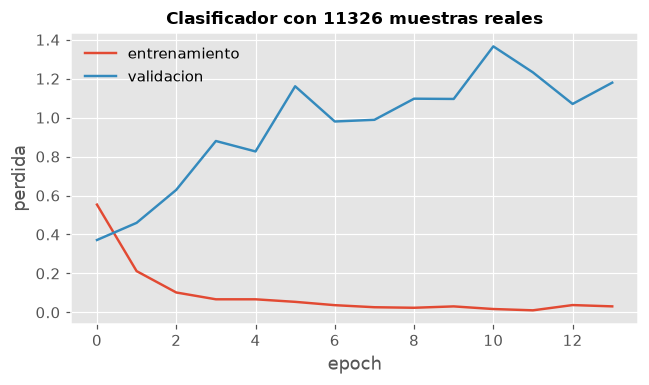

Epochs efectivos: 14


,valor
pr_auc,0.190919
roc_auc,0.552167
f1,0.184332
precision,0.128000
recall,0.329218
umbral,0.180000
vn,1549.000000
fp,545.000000
fn,163.000000
vp,80.000000


In [6]:
clasificador_total, historia_total = modelo.entrenar_clasificador(
    X_train_total, y_train_total, X_val, y_val, semilla=config.SEMILLA, verbose=0)

umbral_total = modelo.umbral_optimo(clasificador_total, X_val, y_val)
metricas_total = modelo.evaluar(clasificador_total, X_test, y_test, umbral=umbral_total)

graficos.curva_perdida(
    historia_total.history,
    f"Clasificador con {len(X_train_total)} muestras reales",
    "02_perdida_train_completo")
plt.show()

print(f"Epochs efectivos: {len(historia_total.history['loss'])}")
display(pd.Series(metricas_total).to_frame("valor"))

## 5. Curva de aprendizaje

Se repite el entrenamiento variando el número de muestras reales disponibles. El
muestreo es estratificado, de modo que la proporción de positivos se mantiene
constante y la única variable es el volumen. Cada tamaño se evalua con varias
semillas para separar el efecto real de la variabilidad del ajuste.

La curva se mide simultáneamente sobre validación y sobre test. La comparación
entre ambas permite distinguir dos fenómenos que de otro modo se confundirian: la
capacidad del modelo de aprovechar más datos y la estabilidad del problema a lo
largo del tiempo.

In [7]:
tamaños = [500, 1000, 2000, 3000, 5000, 8000, len(X_train_total)]
filas_curva = []

for n in tamaños:
    for k in range(config.N_SEMILLAS):
        semilla = config.SEMILLA + k
        X_sub, y_sub = datos.submuestra_real(X_train_total, y_train_total, n, semilla)
        m, h = modelo.entrenar_clasificador(X_sub, y_sub, X_val, y_val, semilla=semilla)
        u = modelo.umbral_optimo(m, X_val, y_val)
        met = modelo.evaluar(m, X_test, y_test, umbral=u)
        met["pr_auc_val"] = modelo.evaluar(m, X_val, y_val, umbral=u)["pr_auc"]
        met.update({"n_reales": len(X_sub), "semilla": semilla,
                    "epochs": len(h.history["loss"])})
        filas_curva.append(met)
    últimas = filas_curva[-config.N_SEMILLAS:]
    print(f"n = {n:>6d}  PR-AUC test = {np.mean([f['pr_auc'] for f in últimas]):.4f}   "
          f"PR-AUC validación = {np.mean([f['pr_auc_val'] for f in últimas]):.4f}")

curva = pd.DataFrame(filas_curva)
resumen_curva = curva.groupby("n_reales").agg(
    pr_auc_media=("pr_auc", "mean"), pr_auc_std=("pr_auc", "std"),
    pr_auc_val_media=("pr_auc_val", "mean"), pr_auc_val_std=("pr_auc_val", "std"),
    f1_media=("f1", "mean"), recall_media=("recall", "mean"),
    epochs_medios=("epochs", "mean")).reset_index()
display(resumen_curva.round(4))

n =    500  PR-AUC test = 0.3041   PR-AUC validación = 0.3334


n =   1000  PR-AUC test = 0.2751   PR-AUC validación = 0.2965


n =   2000  PR-AUC test = 0.2605   PR-AUC validación = 0.3307


n =   3000  PR-AUC test = 0.2917   PR-AUC validación = 0.3295


n =   5000  PR-AUC test = 0.1982   PR-AUC validación = 0.3015


n =   8000  PR-AUC test = 0.2376   PR-AUC validación = 0.3202


n =  11326  PR-AUC test = 0.1917   PR-AUC validación = 0.3043


,n_reales,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,recall_media,epochs_medios
0,500,0.3041,0.0253,0.3334,0.0139,0.2671,0.2189,13.4
1,1000,0.2751,0.0388,0.2965,0.0373,0.2583,0.3292,15.8
2,2000,0.2605,0.0380,0.3307,0.0212,0.2393,0.3860,20.4
3,3000,0.2917,0.0300,0.3295,0.0251,0.2541,0.4000,15.0
4,5000,0.1982,0.0541,0.3015,0.0415,0.2050,0.3185,21.0
5,8000,0.2376,0.0678,0.3202,0.0239,0.2092,0.3498,15.6
6,11326,0.1917,0.0560,0.3043,0.0458,0.1867,0.3350,15.6


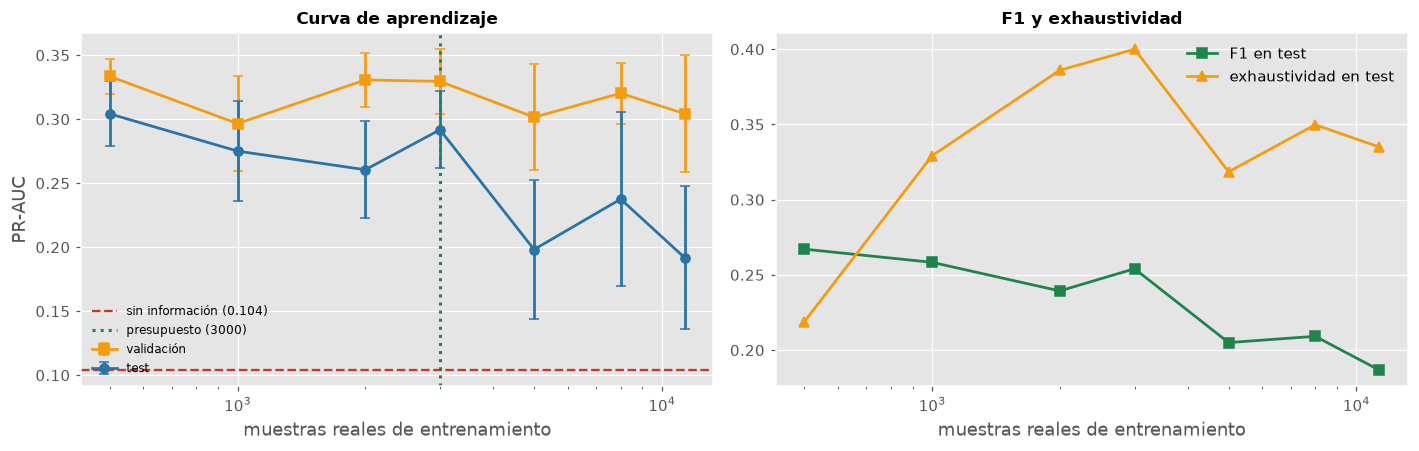

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].errorbar(resumen_curva["n_reales"], resumen_curva["pr_auc_val_media"],
                 yerr=resumen_curva["pr_auc_val_std"], marker="s", capsize=3,
                 color="#f39c12", linewidth=1.8, label="validación")
axes[0].errorbar(resumen_curva["n_reales"], resumen_curva["pr_auc_media"],
                 yerr=resumen_curva["pr_auc_std"], marker="o", capsize=3,
                 color="#2874a6", linewidth=1.8, label="test")
axes[0].axhline(tasa_base, color="#c0392b", linestyle="--",
                label=f"sin información ({tasa_base:.3f})")
axes[0].axvline(config.N_REALES, color="#1e8449", linestyle=":", linewidth=2,
                label=f"presupuesto ({config.N_REALES})")
axes[0].set_xscale("log")
axes[0].set_xlabel("muestras reales de entrenamiento")
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Curva de aprendizaje")
axes[0].legend(fontsize=8)

axes[1].plot(resumen_curva["n_reales"], resumen_curva["f1_media"],
             marker="s", color="#1e8449", linewidth=1.8, label="F1 en test")
axes[1].plot(resumen_curva["n_reales"], resumen_curva["recall_media"],
             marker="^", color="#f39c12", linewidth=1.8, label="exhaustividad en test")
axes[1].set_xscale("log")
axes[1].set_xlabel("muestras reales de entrenamiento")
axes[1].set_title("F1 y exhaustividad")
axes[1].legend()

fig.tight_layout()
graficos.guardar(fig, "02_curva_aprendizaje")
plt.show()

La lectura conjunta de ambas curvas resulta más informativa de lo previsto.

En **validación** el rendimiento es prácticamente plano: pasar de quinientas a
once mil muestras reales no lo mejora de forma apreciable. El clasificador extrae
casi toda la señal disponible con una fracción mínima de los datos, y el resto
son en su mayor parte repeticiones de configuraciones ya vistas, consecuencia
directa del solapamiento entre ventanas documentado en el análisis exploratorio.

En **test** la curva llega incluso a descender. La explicación no es un fallo de
ajuste sino un cambio en el propio problema: entrenar con más historia significa
entrenar con más décadas antiguas, y el periodo de test corresponde a un régimen
de mercado distinto del que domina el conjunto de entrenamiento. El modelo se
especializa en configuraciones que han dejado de ser representativas.

La conclusión metodologica conviene enunciarla sin rodeos: **este problema no
esta limitado por el volumen de datos**. Añadir historia no mejora el resultado.
Lo que escasea es la variedad de episodios de estrés, no el número de
observaciones, y son dos carencias distintas.

### 5.1 La escasez, vista de cerca

Una comprobación adicional ilustra el punto. Si en lugar de muestrear al azar
sobre toda la historia se toman las últimas sesiones del bloque de entrenamiento,
que es la situación de quien dispone únicamente de datos recientes, el resultado
es revelador.

In [9]:
for n in [500, 1000, 2000, 3000]:
    y_reciente = y_train_total[-n:]
    print(f"últimas {n:>5d} ventanas de entrenamiento -> "
          f"{int(y_reciente.sum()):>4d} positivas ({y_reciente.mean():.1%})")

últimas   500 ventanas de entrenamiento ->    0 positivas (0.0%)
últimas  1000 ventanas de entrenamiento ->    0 positivas (0.0%)
últimas  2000 ventanas de entrenamiento ->  257 positivas (12.8%)
últimas  3000 ventanas de entrenamiento ->  337 positivas (11.2%)


Los tramos recientes más cortos no contienen **ningún** episodio de caída severa.
Un clasificador entrenado sobre ellos no puede aprender nada, y no porque le
falten observaciones sino porque le falta el fenómeno entero.

Esto delimita con precisión lo que cabe esperar de un modelo generativo aquí. Su
utilidad no consiste en fabricar más observaciones, que sobran, sino en producir
configuraciones de estrés plausibles y distintas entre si a partir de las pocas
disponibles. Si un generador lo consigue, debería notarse; si se limita a
reproducir lo que ya hay, no cambiara nada.

## 6. Elección del presupuesto de datos reales

El presupuesto queda fijado en el valor de `config.N_REALES`. Se sitúa en la
región donde el clasificador ya extrae señal de forma estable pero dispone aún de
un número reducido de episodios de estrés, y donde la varianza entre semillas se
mantiene manejable. Un presupuesto mucho menor dejaria a los generadores sin
material suficiente con el que aprender la distribución; uno mucho mayor no
cambiaria el resultado, como acaba de mostrar la curva de aprendizaje.

Conviene subrayar un punto metodologico: **los generadores se entrenan
exclusivamente con este mismo subconjunto**, nunca con la totalidad del
histórico. De lo contrario dispondrian de información vedada al clasificador y la
comparación perderia todo sentido.

In [10]:
X_real, y_real = datos.submuestra_real(
    X_train_total, y_train_total, config.N_REALES, config.SEMILLA)

print(f"Presupuesto de datos reales: {len(X_real)} ventanas")
print(f"Positivas: {int(y_real.sum())} ({y_real.mean():.1%})")

fila_presupuesto = resumen_curva.loc[
    resumen_curva["n_reales"] == config.N_REALES].iloc[0]
fila_completo = resumen_curva.loc[
    resumen_curva["n_reales"] == len(X_train_total)].iloc[0]

print(f"\nCon el presupuesto ({config.N_REALES} muestras):")
print(f"  PR-AUC en test:       {fila_presupuesto['pr_auc_media']:.4f} "
      f"+- {fila_presupuesto['pr_auc_std']:.4f}")
print(f"  PR-AUC en validación: {fila_presupuesto['pr_auc_val_media']:.4f}")
print(f"\nCon el histórico completo ({len(X_train_total)} muestras):")
print(f"  PR-AUC en test:       {fila_completo['pr_auc_media']:.4f} "
      f"+- {fila_completo['pr_auc_std']:.4f}")
print(f"  PR-AUC en validación: {fila_completo['pr_auc_val_media']:.4f}")

Presupuesto de datos reales: 3000 ventanas
Positivas: 301 (10.0%)

Con el presupuesto (3000 muestras):
  PR-AUC en test:       0.2917 +- 0.0300
  PR-AUC en validación: 0.3295

Con el histórico completo (11326 muestras):
  PR-AUC en test:       0.1917 +- 0.0560
  PR-AUC en validación: 0.3043


## 7. Búsqueda de la arquitectura

El enunciado pide que la arquitectura del clasificador se busque sobre los datos
reales, no que se dé por supuesta. La rejilla recorre las cuatro decisiones con
más peso sobre la capacidad de la red —profundidad, anchura de los bloques
convolucionales, tamaño del núcleo y regularización— alrededor de la
configuración de referencia, y repite cada una con tres semillas para que el
orden no dependa de una inicialización afortunada.

Dos precisiones sobre el procedimiento:

- **El test no interviene.** La selección se decide únicamente con el presupuesto
  de datos reales y la partición de validación. Consultar el test para elegir la
  arquitectura y después informar sobre él daría una medida inflada del
  rendimiento.
- **Las cifras son optimistas en términos absolutos.** La misma partición de
  validación fija también la parada temprana y el punto de corte, de modo que el
  PR-AUC que aparece aquí no es una estimación limpia del rendimiento fuera de
  muestra. Sirve para ordenar configuraciones entre sí, que es lo que se le pide.

In [11]:
tabla_arquitecturas = modelo.buscar_arquitectura(
    X_real, y_real, X_val, y_val, semillas=3)

ruta_tabla = os.path.join(config.DIR_TABLAS, "busqueda_arquitectura.csv")
tabla_arquitecturas.to_csv(ruta_tabla, index=False)
print()
print(f"Tabla guardada en {ruta_tabla}")

display(tabla_arquitecturas.round(4))

  filtros=32-64-64     kernel=3 densa=100  dropout=0.3  params=  53,001  PR-AUC(val)=0.3033 +- 0.0241


  filtros=64-128-128   kernel=3 densa=100  dropout=0.3  params= 142,665  PR-AUC(val)=0.3310 +- 0.0256   <- referencia


  filtros=64-128-256   kernel=3 densa=100  dropout=0.3  params= 255,945  PR-AUC(val)=0.3358 +- 0.0228


  filtros=64-128-128   kernel=5 densa=100  dropout=0.3  params= 181,961  PR-AUC(val)=0.3483 +- 0.0407


  filtros=64-128-128   kernel=3 densa=50   dropout=0.3  params= 110,565  PR-AUC(val)=0.3179 +- 0.0496


...

  filtros=64-128-128   kernel=3 densa=100  dropout=0.1  params= 142,665  PR-AUC(val)=0.3369 +- 0.0321


  filtros=64-128-128   kernel=3 densa=100  dropout=0.5  params= 142,665  PR-AUC(val)=0.3250 +- 0.0456


  filtros=32-64        kernel=3 densa=100  dropout=0.3  params=  91,849  PR-AUC(val)=0.3009 +- 0.0432


  filtros=64-128       kernel=5 densa=50   dropout=0.5  params= 125,413  PR-AUC(val)=0.3473 +- 0.0290

Tabla guardada en C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\tablas\busqueda_arquitectura.csv


,filtros,kernel,densa,dropout,parametros,pr_auc_val_media,pr_auc_val_std,f1_val_media,epochs_medios,referencia
0,64-128-128,5,100,0.3,181961,0.3483,0.0407,0.3574,22.0000,False
1,64-128,5,50,0.5,125413,0.3473,0.0290,0.4180,21.6667,False
2,64-128-128,3,100,0.1,142665,0.3369,0.0321,0.3799,15.0000,False
3,64-128-256,3,100,0.3,255945,0.3358,0.0228,0.3713,15.3333,False
4,64-128-128,3,100,0.3,142665,0.3310,0.0256,0.3576,16.0000,True
5,64-128-128,3,100,0.5,142665,0.3250,0.0456,0.3772,15.3333,False
6,64-128-128,3,50,0.3,110565,0.3179,0.0496,0.3491,19.3333,False
7,64-128-128,3,200,0.3,206865,0.3152,0.0372,0.3591,14.6667,False
8,32-64-64,3,100,0.3,53001,0.3033,0.0241,0.3413,18.3333,False
9,32-64,3,100,0.3,91849,0.3009,0.0432,0.3427,16.6667,False


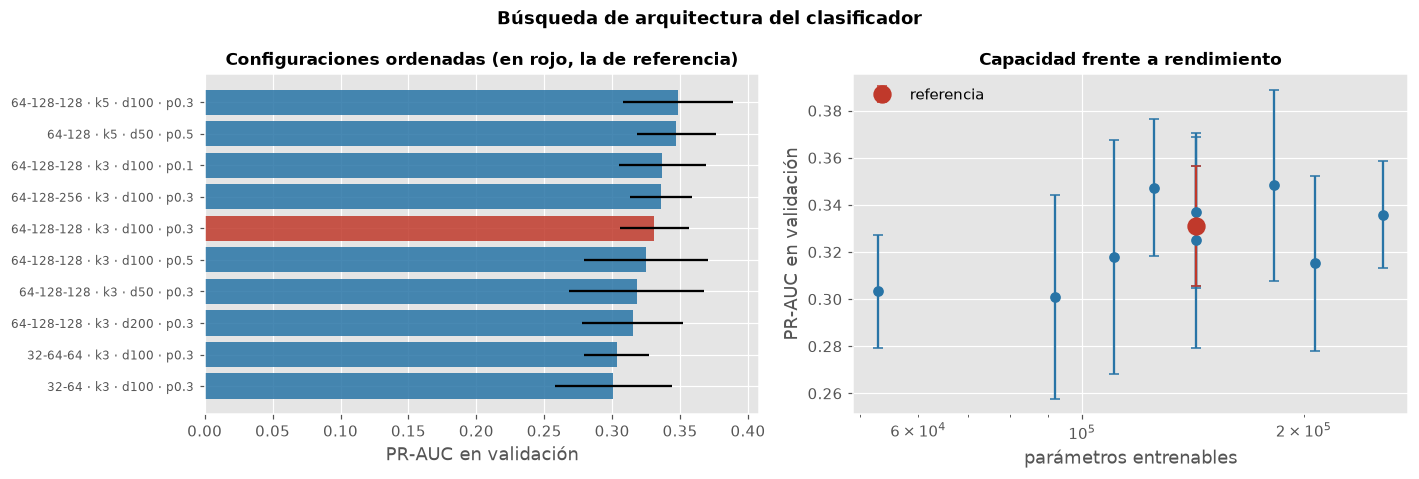

In [12]:
orden = tabla_arquitecturas.sort_values("pr_auc_val_media")
etiquetas = [f"{f['filtros']} · k{f['kernel']} · d{f['densa']} · p{f['dropout']:g}"
             for _, f in orden.iterrows()]
colores = ["#c0392b" if f["referencia"] else "#2874a6" for _, f in orden.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].barh(range(len(orden)), orden["pr_auc_val_media"],
             xerr=orden["pr_auc_val_std"], color=colores, alpha=0.85)
axes[0].set_yticks(range(len(orden)))
axes[0].set_yticklabels(etiquetas, fontsize=8)
axes[0].set_xlabel("PR-AUC en validación")
axes[0].set_title("Configuraciones ordenadas (en rojo, la de referencia)")

axes[1].errorbar(tabla_arquitecturas["parametros"],
                 tabla_arquitecturas["pr_auc_val_media"],
                 yerr=tabla_arquitecturas["pr_auc_val_std"],
                 fmt="o", color="#2874a6", capsize=3, linestyle="none")
referencia = tabla_arquitecturas[tabla_arquitecturas["referencia"]]
axes[1].errorbar(referencia["parametros"], referencia["pr_auc_val_media"],
                 yerr=referencia["pr_auc_val_std"], fmt="o", color="#c0392b",
                 markersize=11, capsize=3, linestyle="none", label="referencia")
axes[1].set_xscale("log")
axes[1].set_xlabel("parámetros entrenables")
axes[1].set_ylabel("PR-AUC en validación")
axes[1].set_title("Capacidad frente a rendimiento")
axes[1].legend()

fig.suptitle("Búsqueda de arquitectura del clasificador", fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "02_busqueda_arquitectura")
plt.show()

In [13]:
mejor = tabla_arquitecturas.iloc[0]
referencia = tabla_arquitecturas[tabla_arquitecturas["referencia"]].iloc[0]

diferencia = mejor["pr_auc_val_media"] - referencia["pr_auc_val_media"]
margen = mejor["pr_auc_val_std"] + referencia["pr_auc_val_std"]

print(f"Mejor configuración:  filtros {mejor['filtros']}, "
      f"kernel {mejor['kernel']}, densa {mejor['densa']}, "
      f"dropout {mejor['dropout']:g}")
print(f"  PR-AUC(val) {mejor['pr_auc_val_media']:.4f} "
      f"+- {mejor['pr_auc_val_std']:.4f}   "
      f"({mejor['parametros']:,} parámetros)")
print("Configuración de referencia:")
print(f"  PR-AUC(val) {referencia['pr_auc_val_media']:.4f} "
      f"+- {referencia['pr_auc_val_std']:.4f}   "
      f"({referencia['parametros']:,} parámetros)")
print()
print(f"Diferencia: {diferencia:+.4f}    "
      f"dispersión combinada entre semillas: {margen:.4f}")
print()

if diferencia <= margen:
    print("La ventaja de la mejor configuración no supera la dispersión entre")
    print("semillas: la rejilla no distingue arquitecturas de forma fiable. Se")
    print("mantiene la de referencia, que es la del material del taller.")
else:
    print("La mejor configuración supera a la de referencia por encima de la")
    print("dispersión entre semillas. Conviene revisar la elección antes de")
    print("ejecutar la comparativa entre generadores.")

Mejor configuración:  filtros 64-128-128, kernel 5, densa 100, dropout 0.3
  PR-AUC(val) 0.3483 +- 0.0407   (181,961 parámetros)
Configuración de referencia:
  PR-AUC(val) 0.3310 +- 0.0256   (142,665 parámetros)

Diferencia: +0.0173    dispersión combinada entre semillas: 0.0662

La ventaja de la mejor configuración no supera la dispersión entre
semillas: la rejilla no distingue arquitecturas de forma fiable. Se
mantiene la de referencia, que es la del material del taller.


El criterio de decisión es deliberadamente conservador: la arquitectura sólo se
cambiaría si la ventaja superase la dispersión entre semillas. En un problema tan
ruidoso, quedarse con la media más alta sin comprobar ese margen equivale a
ajustar la red al azar de la inicialización.

Si la rejilla no llega a distinguir configuraciones, mantener la de referencia
tiene además una ventaja práctica: es la que emplean los cuatro notebooks de
generadores, de modo que las tablas ya calculadas en `results/tablas/` siguen
siendo válidas.

## 8. Referencia definitiva

Se ejecuta por último el protocolo de evaluación común con el presupuesto fijado
y sin ningún dato sintético. El resultado es la fila de referencia frente a la
que se compararan todos los generadores, y se genera con exactamente el mismo
código que ellos utilizaran, de modo que ninguna diferencia pueda atribuirse al
procedimiento de medida.

In [14]:
resultados_baseline, historias_baseline = experimento.barrido_ratios(
    "baseline", X_real, y_real, None, None,
    X_val, y_val, X_test, y_test, ratios=[0.0])

ruta = experimento.guardar_resultados(resultados_baseline, "baseline")
print(f"\nGuardado en {ruta}")
display(experimento.resumir(resultados_baseline).round(4))

  baseline   ratio=0.00  semilla=42 PR-AUC(test)=0.3369 PR-AUC(val)=0.3280 F1=0.2770


  baseline   ratio=0.00  semilla=43 PR-AUC(test)=0.2842 PR-AUC(val)=0.3579 F1=0.2659


  baseline   ratio=0.00  semilla=44 PR-AUC(test)=0.1357 PR-AUC(val)=0.3070 F1=0.1687


  baseline   ratio=0.00  semilla=45 PR-AUC(test)=0.1199 PR-AUC(val)=0.3166 F1=0.1709


  baseline   ratio=0.00  semilla=46 PR-AUC(test)=0.2497 PR-AUC(val)=0.3471 F1=0.2315

Guardado en C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\tablas\resultados_baseline.csv


,modelo,ratio,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,f1_std,recall_media,precision_media,n_sinteticos
0,baseline,0.0,0.2253,0.0944,0.3314,0.0211,0.2228,0.0512,0.3284,0.2041,0


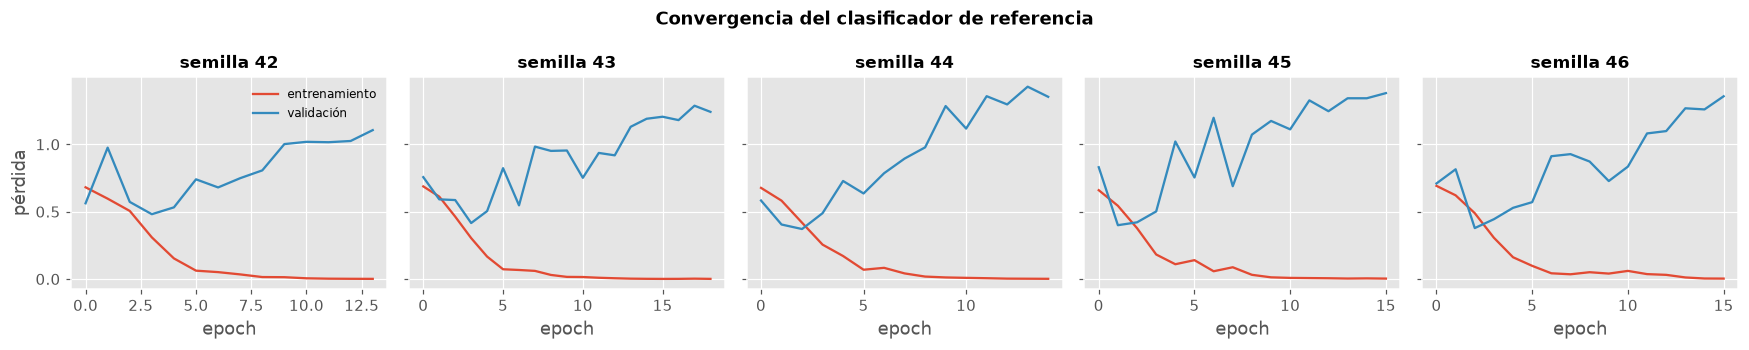

In [15]:
n_paneles = min(config.N_SEMILLAS, len(historias_baseline))
fig, axes = plt.subplots(1, n_paneles, figsize=(3.2 * n_paneles, 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, ((ratio, semilla), historia) in zip(axes, sorted(historias_baseline.items())):
    ax.plot(historia["loss"], label="entrenamiento", linewidth=1.5)
    ax.plot(historia["val_loss"], label="validación", linewidth=1.5)
    ax.set_title(f"semilla {semilla}")
    ax.set_xlabel("epoch")

axes[0].set_ylabel("pérdida")
axes[0].legend(fontsize=8)
fig.suptitle("Convergencia del clasificador de referencia", fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "02_perdida_baseline")
plt.show()

## Conclusiones del notebook

1. **La arquitectura extrae señal real.** El PR-AUC supera con holgura la tasa
   base de un clasificador sin información, lo que confirma que la ventana de
   rentabilidades contiene información sobre el riesgo de caída a treinta días.
2. **En términos absolutos el rendimiento es modesto.** Era lo esperable a la
   vista del solapamiento entre clases documentado en el análisis exploratorio.
   Anticipar caídas de mercado es un problema difícil, y unas metricas
   espectaculares habrian sido más motivo de sospecha que de satisfacción.
3. **El problema no esta limitado por el volumen de datos.** La curva de
   aprendizaje es plana en validación y descendente en test. Multiplicar por
   veinte el número de observaciones no mejora el resultado, porque las ventanas
   se solapan y aportan poca información nueva, y porque la historia más antigua
   corresponde a un régimen distinto del que se evalua.
4. **Lo que escasea es la variedad de episodios de estrés.** Los tramos recientes
   del entrenamiento llegan a no contener ninguno. Esta es la carencia concreta
   que un modelo generativo podría compensar, y la que se pone a prueba en los
   notebooks siguientes.
5. **La comparación se apoyara en validación y test a la vez.** Dado que el test
   cubre un único régimen de mercado y sus metricas son ruidosas, atender a una
   sola de las particiones daría lugar a conclusiones fragiles.
6. **Queda establecida la referencia** frente a la que se mediran los cuatro
   generadores, obtenida con el mismo protocolo que se aplicara a todos ellos.